In [1]:
using DataFrames, Chain, Statistics, CSV

In [2]:
census = CSV.read("../assets/datasets/Gaz_ua_national.csv",DataFrame)
names(census)

11-element Vector{String}:
 "GEOID"
 "NAME"
 "UATYPE"
 "POP10"
 "HU10"
 "ALAND"
 "AWATER"
 "ALAND_SQMI"
 "AWATER_SQMI"
 "INTPTLAT"
 "INTPTLONG"

### What is the total population of all areas?


In [4]:
@chain census begin
  combine(:POP10 => sum => :TOTAL_POP)
end

Row,TOTAL_POP
,Int64
1,252746527


In [6]:
@chain census begin
  select(:NAME, :POP10)
  sort(:POP10, rev = true)
  first(10)
end

Row,NAME,POP10
,String,Int64
1,"New York--Newark, NY--NJ--CT Urbanized Area",18351295
2,"Los Angeles--Long Beach--Anaheim, CA Urbanized Area",12150996
3,"Chicago, IL--IN Urbanized Area",8608208
4,"Miami, FL Urbanized Area",5502379
5,"Philadelphia, PA--NJ--DE--MD Urbanized Area",5441567
6,"Dallas--Fort Worth--Arlington, TX Urbanized Area",5121892
7,"Houston, TX Urbanized Area",4944332
8,"Washington, DC--VA--MD Urbanized Area",4586770
9,"Atlanta, GA Urbanized Area",4515419


In [8]:
@chain census begin
  subset(:INTPTLONG => long -> long .< -120)
  combine(:POP10 => sum => :POP_WEST_120)
end

Row,POP_WEST_120
,Int64
1,21932350


In [9]:
using CairoMakie
CairoMakie.activate!()
Makie.inline!(true)

true

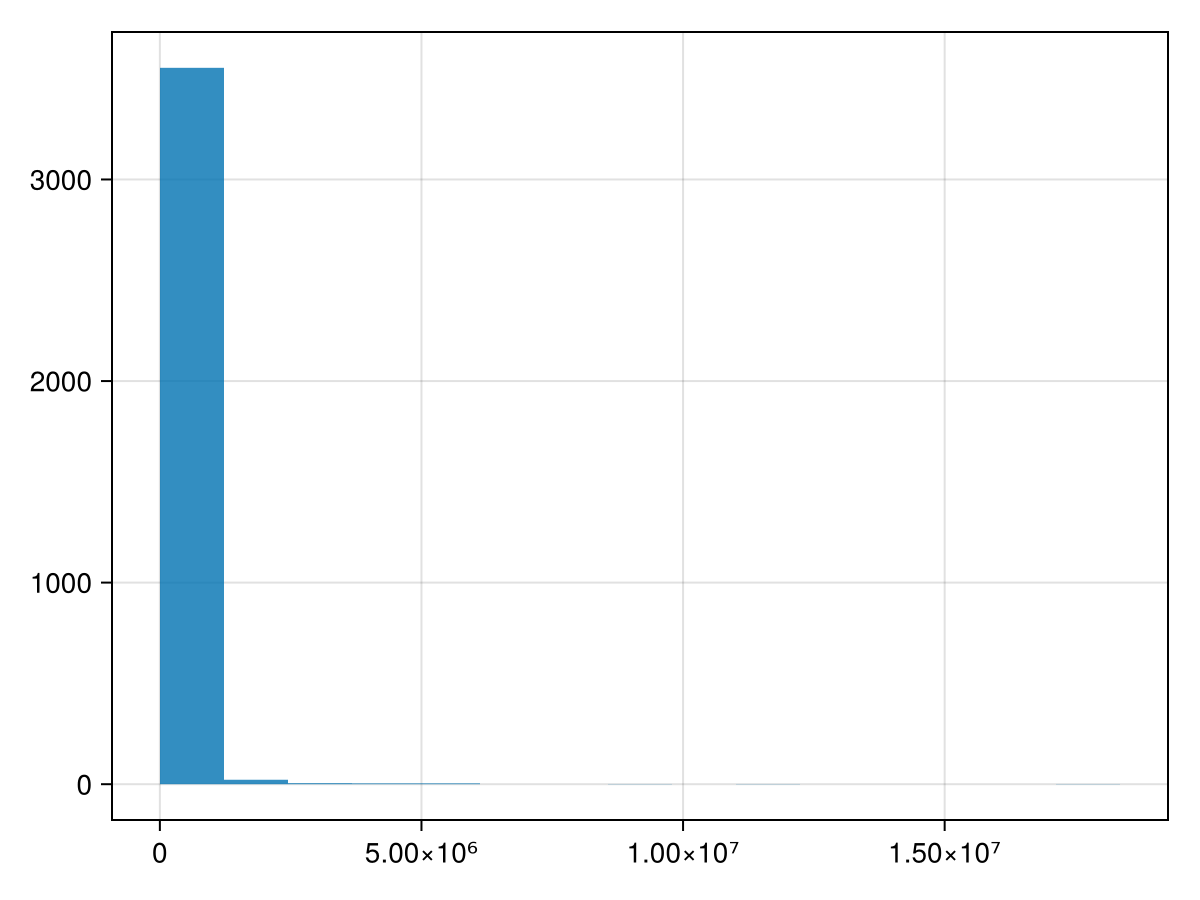

In [11]:
fig = hist(census.POP10)

In [12]:
save("../assets/plots/census/hist01.png",fig)

CairoMakie.Screen{IMAGE}


11-element Vector{Float64}:
   1000.0
   3162.2776601683795
  10000.0
  31622.776601683792
 100000.0
 316227.7660168379
      1.0e6
      3.1622776601683795e6
      1.0e7
      3.162277660168379e7
      1.0e8

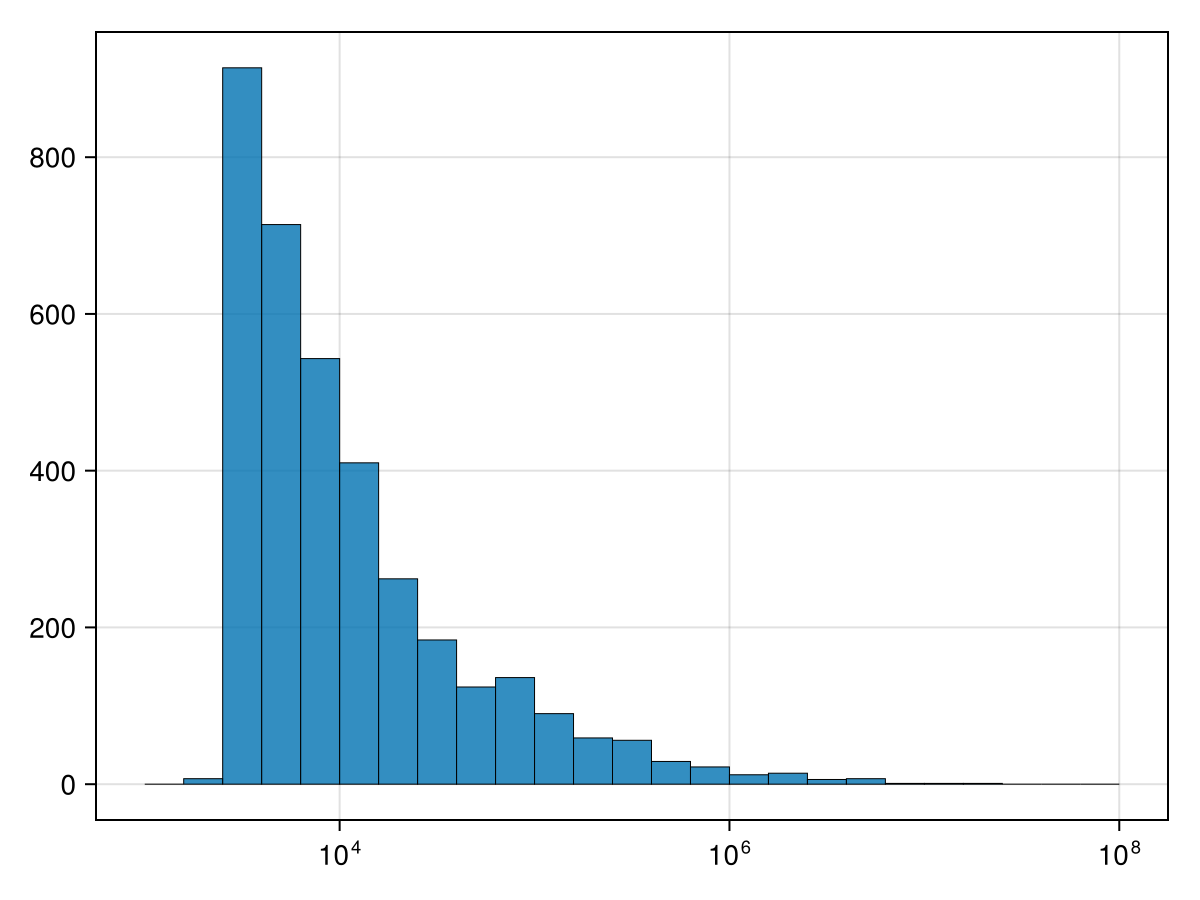

In [30]:
b=10 .^(3:0.2:8)
fig = Figure()
ax = Axis(fig[1,1], xscale = log10)
hist!(ax, census.POP10, bins=b, strokewidth=0.5)
fig

In [31]:
save("../assets/plots/census/hist02.png",fig)

CairoMakie.Screen{IMAGE}


In [10]:
sum(census_data.POP10)

252746527

In [32]:
@chain census begin
  transform( [:POP10, :HU10] => ((p,h)-> p./h) => :Housing_Density)
  select(:NAME, :Housing_Density)
  sort(:Housing_Density, rev=true)
  first(10)
end

Row,NAME,Housing_Density
,String,Float64
1,"Air Force Academy, CO Urban Cluster",16.908
2,"Colorado City, AZ--UT Urban Cluster",8.1839
3,"Kinross, MI Urban Cluster",6.75773
4,"Soledad, CA Urban Cluster",6.61642
5,"Alfred, NY Urban Cluster",6.55842
6,"Avenal, CA Urban Cluster",6.44713
7,"Corcoran, CA Urban Cluster",6.12188
8,"Montgomery, PA Urban Cluster",5.83454
9,"Darbydale, OH Urban Cluster",5.6216


In [12]:
@chain census_data begin
  combine(:HU10 => sum)
end

Row,HU10_sum
,Int64
1,105549535


In [13]:
@chain census_data begin
  select(:NAME, :ALAND)
  sort(:ALAND, rev=true)
  first(10)
end

Row,NAME,ALAND
,String,Int64
1,"New York--Newark, NY--NJ--CT Urbanized Area",8935981360
2,"Atlanta, GA Urbanized Area",6851428985
3,"Chicago, IL--IN Urbanized Area",6326686332
4,"Philadelphia, PA--NJ--DE--MD Urbanized Area",5131721516
5,"Boston, MA--NH--RI Urbanized Area",4852227548
6,"Dallas--Fort Worth--Arlington, TX Urbanized Area",4607936452
7,"Los Angeles--Long Beach--Anaheim, CA Urbanized Area",4496266014
8,"Houston, TX Urbanized Area",4299420988
9,"Detroit, MI Urbanized Area",3463234750


In [14]:
@chain census_data begin
  select(:NAME, :AWATER)
  sort(:AWATER, rev=true)
  first(10)
end

Row,NAME,AWATER
,String,Int64
1,"New York--Newark, NY--NJ--CT Urbanized Area",533176599
2,"Minneapolis--St. Paul, MN--WI Urbanized Area",232127029
3,"Tampa--St. Petersburg, FL Urbanized Area",211394181
4,"Boston, MA--NH--RI Urbanized Area",201870511
5,"Jacksonville, FL Urbanized Area",199369291
6,"Miami, FL Urbanized Area",191964476
7,"Virginia Beach, VA Urbanized Area",189979138
8,"Seattle, WA Urbanized Area",173839079
9,"Orlando, FL Urbanized Area",142321970


###  List the top 5 Massachusetts areas  by population.

In [36]:
@chain census begin
  subset(:NAME => (n -> occursin.("MA",n)))
  sort(:POP10, rev= true)
  first(5)
  select(:NAME, :POP10)
end

Row,NAME,POP10
,String,Int64
1,"Boston, MA--NH--RI Urbanized Area",4181019
2,"Providence, RI--MA Urbanized Area",1190956
3,"Springfield, MA--CT Urbanized Area",621300
4,"Worcester, MA--CT Urbanized Area",486514
5,"Barnstable Town, MA Urbanized Area",246695


In [18]:
@chain census_data begin
  subset(:NAME => n -> occursin.("MA",n))
  combine(:POP10 => mean, :POP10 => median, :POP10 => std)
end

Row,POP10_mean,POP10_median,POP10_std
,Float64,Float64,Float64
1,3.69408e5,20717.5,9.44398e5
